In [1]:
import numpy as np
import pandas as pd
import matplotlib
print(matplotlib.__version__)
matplotlib.use('PDF')
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import matplotlib.lines as mlines
from glob import glob
from collections import Counter
#import ns
import history_cmc as hic
import math
import scipy
#from scipy.interpolate import interp1d
#from scipy import stats
import matplotlib.cm as cm
import matplotlib as mpl
import random
from random import shuffle
import gzip
import sys
import astropy
from astropy import units
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
print('done')

#import gw_ecc_calc as gwcalc
#import unit_convert as uc
#import merger_rate_calculator as mr
#import ns_tidalcapture as tc
import conversions
import dynamics as dyn
print('done')

%matplotlib inline

matplotlib.rcParams.update({'font.size': 24})

sys.path.insert(1, '/projects/b1095/syr904/MyCodes/cmctoolkit')
import cmctoolkit as cmct
      
twopi=2.*np.pi
yearsc=3.1557*10**7
Kconst=9.87*10**-48 ##yr/G^2
Gconst=6.674*10**-8 ##cm3*g-1*s-2
Gconst_sun = 4.30091*10**-3 ##pc*M_sun**-1*(km/s)^2
clight=3*10**10 ##cm/s
Msun=2*10**33 ##gram
AU=1.496*10**13  ##cm
AU_Rsun=214.93946938362 ##AU to R_sun
PC=3.086*10**18  ##cm
PC_Rsun = 44334448.0068964 ##pc to R_sun

3.10.3
done
done


10.549322533847999


/projects/b1095/syr904/MyCodes/cmctoolkit/cmctoolkit.py:980: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.data['obsMag_' + filtnames[ii]] = self.data['absMag_' + filtnames[ii]]
/projects/b1095/syr904/MyCodes/cmctoolkit/cmctoolkit.py:1000: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.data['bin_obsMag0_' + filtnames[ii]] = self.data['bin_absMag0_' + filtnames[ii]]
/projects/b1095/syr904/MyCodes/cmctoolkit/cmctoolkit.py:1020: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `fra

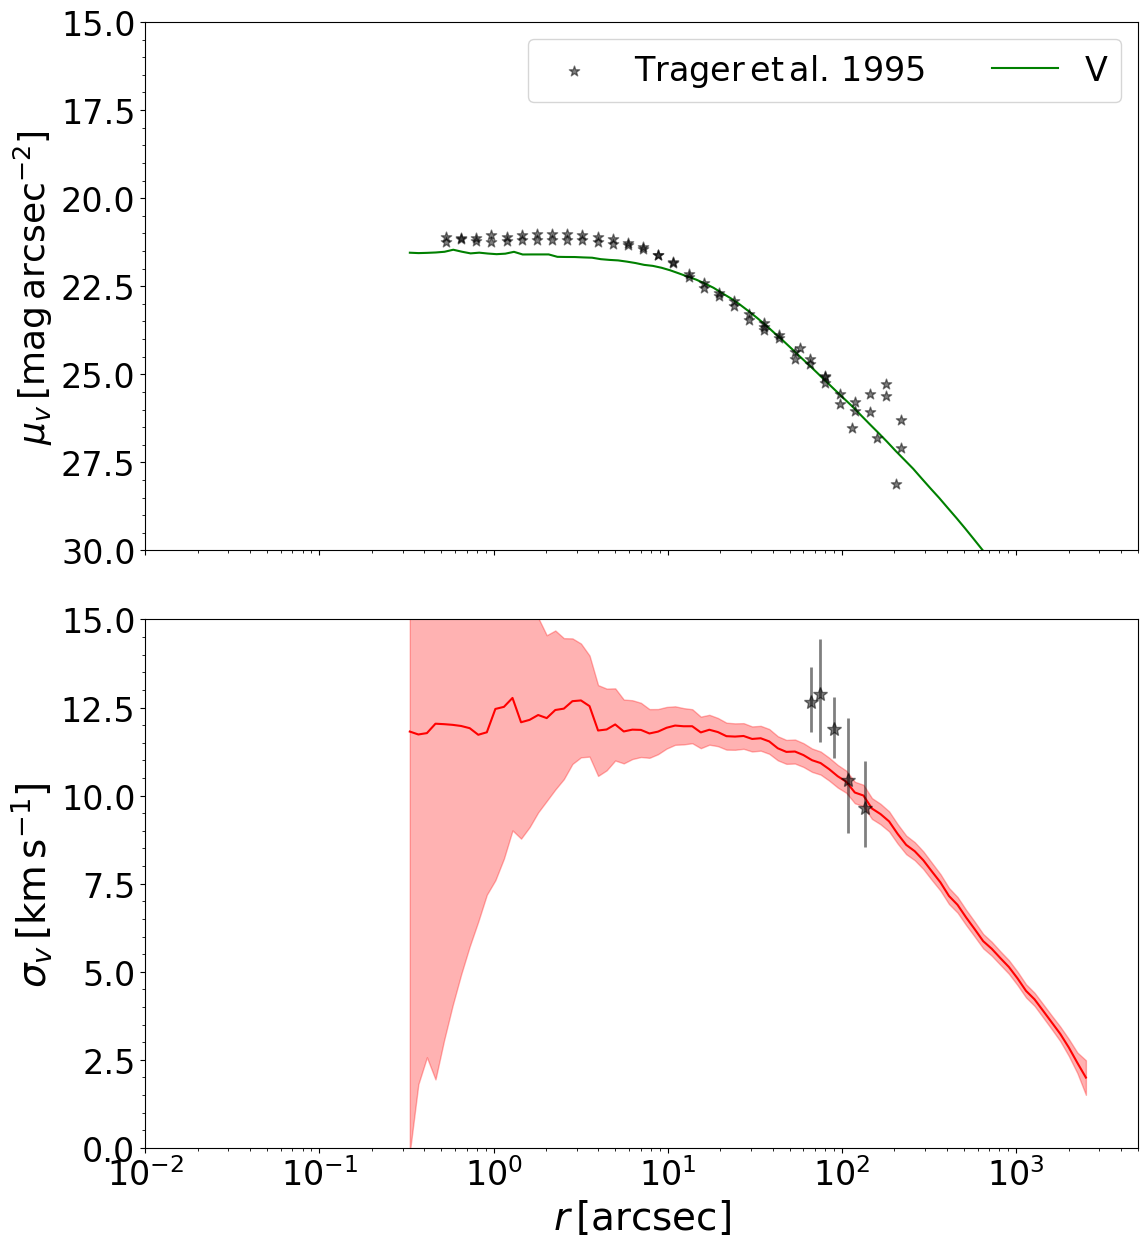

In [5]:
###Ter 5
path = '/projects/b1095/syr904/cmc/CMC-COSMIC/master_tc_test/ver_0601/MOCHA47Tuc_elson_rv4_3e6_tcon/'

E_BV = 2.28  # Harris 1996, 2010 edition
dist = 6.62 # Baumgardt et al. 2019, kpc
Av = 3.1 * E_BV # Cardelli 1989

##Surface brightness and velocity dispersion profiles
###Observations###
R_sun_obs=6.62
ngcno='terzan5'
ngcno1='Ter5'

ft = open('makeSBP/trager.dat','r')
linest = ft.readlines()


fv = open('makeSBP/vel_dispersion_profiles_100423.dat','r')
linesv = fv.readlines()

flag = 0
#### find observed SBP from trager file
arcsec_t = []
SB_t = []
for k in range(len(linest)):
    linet = linest[k]
    linet = linet.split('\n')
    linet = linet[0]
    linet = linet.split('\t')
    cluster_tregar = linet[1]
    if cluster_tregar == ngcno:
        arcsec_t.append(float(linet[2]))
        SB_t.append(float(linet[3]))
        flag = 1
arcsec_t = np.array(arcsec_t[:])
SB_t = np.array(SB_t[:])
if flag == 0:
        print('Trager doesnt have the SBP or sigma v profile')
        sys.exit()

flag = 0
#### find observed sigma_v profile
datav = np.genfromtxt('makeSBP/vel_dispersion_profiles_100423.dat')
R_obs = [] # in arcsec
sigma_obs = []
sigma_err_obs_up = []
sigma_err_obs_down = []
for k in range(len(linesv)):
    linev = linesv[k]
    linev = linev.split('\n')
    linev = linev[0]
    linev = linev.split(' ')
    cluster_sigma = linev[0]
    if cluster_sigma == ngcno1:
        R_obs.append(datav[k,1])
        sigma_obs.append(datav[k,2])
        sigma_err_obs_up.append(datav[k,3])
        sigma_err_obs_down.append(datav[k,4])
        flag = 1
R_obs = np.array(R_obs[:])
sigma_obs = np.array(sigma_obs[:])
sigma_err_obs_up = np.array(sigma_err_obs_up[:])
sigma_err_obs_down = np.array(sigma_err_obs_down[:])
############
if flag == 0:
        print('No observed sigmav profile')
        sys.exit()
        


###Models###
snap_h5 = 'initial.snapshots.h5'

snap = cmct.Snapshot(fname=path+snap_h5, snapshot_name='/733(t=0.47867046)', conv=path+'initial.conv.sh', 
                     dist=6.62, # distance to cluster in kpc
                     z=0.012)
print(snap.age)
##First Check

##Surface brightness and Velocity dispersion profile


###############################################
##Make surface brightness profile
snap.add_photometry('/projects/b1095/syr904/MyCodes/cmctoolkit/filt_index.txt')
v_bincenter, v_profile = snap.make_smoothed_brightness_profile('V', bins=80,
                                                               min_mass=None, max_mass=None,
                                                               max_lum=15, fluxdict=None,
                                                               startypes=np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
                                                               min_logr=-2.0)


# Make velocity dispersion profiles
star_velbin_center, star_veldisp_profile, star_e_veldisp_profile = snap.make_smoothed_veldisp_profile(bins=80,
                                                                 min_mass=None,
                                                                 max_mass=None,
                                                                 dmax=None,
                                                                 fluxdict=None,
                                                                 startypes=np.array([2, 3, 4, 5, 6, 7, 8, 9]),
                                                                 min_logr=-2.0)

star_velbin_arcsec = conversions.pc_to_arcsec(star_velbin_center,R_sun_obs)


##Make number density profile
star_numbin_center, star_profile, star_e_profile = snap.make_smoothed_number_profile(bins=80,
                                                 min_mass=None,
                                                 max_mass=None,
                                                 fluxdict=None,
                                                 startypes=np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
                                                 min_logr=-2.0)

star_numbin_arcsec = conversions.pc_to_arcsec(star_numbin_center,R_sun_obs)
star_profile_arcsec = star_profile/(conversions.pc_to_arcsec(1.,R_sun_obs**2))
star_e_profile_arcsec = star_e_profile/(conversions.pc_to_arcsec(1.,R_sun_obs)**2)

fig, ax=plt.subplots(2, 1, sharex=True,  figsize=(12,13))
#ax[0].set_title(r'$\rm{NGC}\ $'+ngcno, fontsize=20)
ax[0].scatter(10**arcsec_t[:], SB_t[:], facecolor='k', marker = '*', 
              alpha=0.5, s=60, label=r'$\rm{Trager\,et\,al.\,1995}$', zorder=3)
ax[0].plot(v_bincenter, v_profile+Av, c='g', label='V')

ax[1].errorbar(R_obs,sigma_obs,yerr=[sigma_err_obs_down,sigma_err_obs_up], fmt='*', 
               markersize = 10, alpha=0.5, c='k', lw=2.0, zorder=3)
ax[1].scatter([10000,10000], [-5,-5], c='k', marker = '*', alpha=0.5, s=60)
ax[1].plot(star_velbin_arcsec, star_veldisp_profile, c='r', label='Stars')
ax[1].fill_between(star_velbin_arcsec, star_veldisp_profile - star_e_veldisp_profile,
                                  star_veldisp_profile + star_e_veldisp_profile, color='r', alpha=0.3)


ax[0].yaxis.set_minor_locator(AutoMinorLocator())
ax[0].set_ylim(30,15)
ax[0].set_xscale('log')
ax[0].set_xlim(0.01,5000)
ax[0].set_ylabel(r'$\mu_v\,[\rm{mag\,arcsec^{-2}}]$',fontsize=26)
ax[0].legend(loc='best',scatterpoints=1, ncol=2, prop={'size': 24})

ax[1].yaxis.set_minor_locator(AutoMinorLocator())
ax[1].set_xscale('log')
ax[1].set_xlim(0.01,5000)
ax[1].set_ylim(0, 15)
ax[1].set_xlabel(r'$r\,[\rm{arcsec}]$',fontsize=28)
ax[1].set_ylabel(r'$\sigma_v\,[\rm{km\,s^{-1}}]$',fontsize=28)
#ax[1].legend(loc=3,scatterpoints=1, ncol=2, prop={'size': 24})

plt.subplots_adjust(hspace=0.05)
fig.tight_layout()